In [1]:
# Decon Split-Based Contamination Analysis

# This notebook aggregates per-split contamination stats and builds a combined table with:
# - Percent contamination by split (train/validation/test)
# - Raw count of contaminated eval instances by split
# - Number of contaminated training documents by split
#
# Data sources:
# - Eval totals per split: `eval_stats/{train,validation,test}.csv`
# - Decon stats per split: `decon_stats_{train,validation,test}/eval_instances_by_suite.csv`
#                          `decon_stats_{train,validation,test}/training_docs_by_suite.csv`



In [2]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/ianmagnusson/projects/ai2/decon")
EVAL_STATS_DIR = BASE_DIR / "eval_stats"
DECON_STATS = {
    "train": BASE_DIR / "decon_stats_train",
    "validation": BASE_DIR / "decon_stats_validation",
    "test": BASE_DIR / "decon_stats_test",
}

assert EVAL_STATS_DIR.exists(), f"Missing eval_stats dir: {EVAL_STATS_DIR}"
for split, p in DECON_STATS.items():
    assert p.exists(), f"Missing decon stats dir for {split}: {p}"

EVAL_TOTALS_FILES = {
    "train": EVAL_STATS_DIR / "train.csv",
    "validation": EVAL_STATS_DIR / "validation.csv",
    "test": EVAL_STATS_DIR / "test.csv",
}
for split, p in EVAL_TOTALS_FILES.items():
    assert p.exists(), f"Missing eval totals csv for {split}: {p}"



In [3]:
def load_eval_totals(path: Path) -> pd.DataFrame:
    """Load eval totals CSV and return DataFrame with columns: eval, total.
    We take the max across [questions, answers, passages] as the total instances.
    """
    df = pd.read_csv(path)
    # Normalize column names
    cols = {c: c.strip() for c in df.columns}
    df.rename(columns=cols, inplace=True)
    # Some datasets only have one of these non-zero; use max across them
    for col in ["questions", "answers", "passages"]:
        if col not in df.columns:
            df[col] = 0
    df["total"] = df[["questions", "answers", "passages"]].max(axis=1)
    # Standardize key
    df = df[["eval_name", "total"]].rename(columns={"eval_name": "eval"})
    return df


def load_decon_eval_instances(dir_path: Path) -> pd.DataFrame:
    df = pd.read_csv(dir_path / "eval_instances_by_suite.csv")
    return df.rename(columns={"eval_suite": "eval", "unique_eval_instances": "instances_contaminated"})


def load_decon_contam_docs(dir_path: Path) -> pd.DataFrame:
    df = pd.read_csv(dir_path / "training_docs_by_suite.csv")
    return df.rename(columns={"eval_suite": "eval", "training_docs_contaminated": "docs_contaminated"})



In [4]:
# Load per-split totals and contamination aggregates
split_totals = {s: load_eval_totals(p) for s, p in EVAL_TOTALS_FILES.items()}
split_instances = {s: load_decon_eval_instances(DECON_STATS[s]) for s in DECON_STATS}
split_docs = {s: load_decon_contam_docs(DECON_STATS[s]) for s in DECON_STATS}

# Quick sanity rows
{ s: df.shape for s, df in split_totals.items() }, { s: df.shape for s, df in split_instances.items() }, { s: df.shape for s, df in split_docs.items() }


({'train': (132, 2), 'validation': (53, 2), 'test': (98, 2)},
 {'train': (50, 2), 'validation': (23, 2), 'test': (47, 2)},
 {'train': (50, 2), 'validation': (23, 2), 'test': (47, 2)})

In [5]:
# Build combined table
from functools import reduce

def combine_split(split: str) -> pd.DataFrame:
    total = split_totals[split].copy()
    total.rename(columns={"total": f"total_{split}"}, inplace=True)
    inst = split_instances[split].copy().rename(columns={"instances_contaminated": f"instances_{split}"})
    docs = split_docs[split].copy().rename(columns={"docs_contaminated": f"docs_{split}"})
    out = reduce(lambda l, r: pd.merge(l, r, on="eval", how="outer"), [total, inst, docs])
    # Percent contamination for this split
    out[f"pct_{split}"] = (out[f"instances_{split}"] / out[f"total_{split}"]) * 100
    return out

combined = reduce(
    lambda l, r: pd.merge(l, r, on="eval", how="outer"),
    [combine_split("train"), combine_split("validation"), combine_split("test")]
)

# Fill NaNs for counts with zeros where appropriate
for col in [c for c in combined.columns if c.startswith(("instances_", "docs_", "total_"))]:
    combined[col] = combined[col].fillna(0).astype(int)
for col in [c for c in combined.columns if c.startswith("pct_")]:
    combined[col] = combined[col].fillna(0.0)

# Sort by test percent descending by default
combined_sorted = combined.sort_values(by="pct_test", ascending=False).reset_index(drop=True)
combined_sorted.head(20)


,eval,total_train,instances_train,docs_train,pct_train,total_validation,instances_validation,docs_validation,pct_validation,total_test,instances_test,docs_test,pct_test
0,gsm8k,7473,7472,117903,99.986618,0,0,0,0.000000,1319,1319,2675,100.000000
1,hendrycks_math_intermediate_algebra,1295,1074,7599,82.934363,0,0,0,0.000000,903,675,1725,74.750831
2,hendrycks_math_precalculus,746,579,4942,77.613941,0,0,0,0.000000,546,391,930,71.611722
3,hendrycks_math_geometry,870,654,3155,75.172414,0,0,0,0.000000,479,284,601,59.290188
4,tulu3_do_anything_now,0,0,0,0.000000,0,0,0,0.000000,300,134,126,44.666667
5,math_500,0,0,0,0.000000,0,0,0,0.000000,500,222,493,44.400000
6,hendrycks_math_number_theory,869,488,2919,56.156502,0,0,0,0.000000,540,237,542,43.888889
7,hendrycks_math_counting_and_probability,771,461,2597,59.792477,0,0,0,0.000000,474,193,388,40.717300
8,hendrycks_math_algebra,1744,968,8577,55.504587,0,0,0,0.000000,1187,453,1067,38.163437
9,hendrycks_math_prealgebra,1205,599,5825,49.709544,0,0,0,0.000000,871,264,498,30.309989


In [6]:
# Collapse evaluation suites by prefix (mirror decon_analysis aggregation)
prefixes = [
    "agi_eval_",
    "aime_2025",
    "alpaca-",
    "basic_skills_",
    "bbh_",
    "gpqa_",
    "harmbench_",
    "hendrycks_math_",
    "humaneval_",
    "multilingual_mbpp_",
    "multipl_e_",
    "ai2_arc_",
    "bigcodebench",
    "omega_compositional_",
]

AGGREGATE_NAME_OVERRIDES = {
    "hendrycks_math_": "minerva",
    "multipl_e_": "multipl-e-humaneval",
    "multilingual_mbpp_": "multipl-e-mbpp",
    "ai2_arc_": "arc",
    "bigcodebench": "bigcodebench",
    "humaneval_": "humaneval",
    "basic_skills_": "basic",
}

def match_prefix(name: str) -> str | None:
    for prefix in prefixes:
        if name.startswith(prefix):
            return prefix
    return None


def collapse_simple_table(
    df: pd.DataFrame,
    name_col: str,
    sum_cols: list[str],
    dataset_count_col: str = "dataset_count",
    suffix: str = " (aggregated)",
    sort_by: str | None = None,
) -> pd.DataFrame:
    df_copy = df.copy()
    df_copy["prefix_match"] = df_copy[name_col].apply(match_prefix)

    prefixed_rows = df_copy[df_copy["prefix_match"].notna()]
    non_prefixed_rows = df_copy[df_copy["prefix_match"].isna()]

    base_columns = [name_col, dataset_count_col] + list(sum_cols)

    if not prefixed_rows.empty:
        sums = prefixed_rows.groupby("prefix_match")[sum_cols].sum(min_count=1)
        counts = prefixed_rows.groupby("prefix_match").size()
        aggregated = sums.copy()
        aggregated[dataset_count_col] = counts
        aggregated[name_col] = [
            AGGREGATE_NAME_OVERRIDES.get(prefix, f"{prefix}{suffix}")
            for prefix in aggregated.index
        ]
        aggregated = aggregated.reset_index(drop=True)[base_columns]
    else:
        aggregated = pd.DataFrame(columns=base_columns)

    if not non_prefixed_rows.empty:
        non_prefixed_rows = non_prefixed_rows.assign(**{dataset_count_col: 1})
        non_prefixed_rows = non_prefixed_rows[base_columns]
    else:
        non_prefixed_rows = pd.DataFrame(columns=base_columns)

    collapsed = pd.concat([aggregated, non_prefixed_rows], ignore_index=True)

    if sort_by and sort_by in collapsed.columns:
        collapsed = collapsed.sort_values(sort_by, ascending=False, na_position="last")

    return collapsed.reset_index(drop=True)

# Collapse the combined per-split table across known prefixes
sum_cols = [
    "total_train", "instances_train", "docs_train",
    "total_validation", "instances_validation", "docs_validation",
    "total_test", "instances_test", "docs_test",
]

combined_for_collapse = combined.copy()
collapsed_combined = collapse_simple_table(
    combined_for_collapse,
    name_col="eval",
    sum_cols=sum_cols,
    dataset_count_col="dataset_count",
    sort_by=None,
)

# Recompute percentages on collapsed totals
for split in ["train", "validation", "test"]:
    collapsed_combined[f"pct_{split}"] = (
        collapsed_combined[f"instances_{split}"]
        .where(collapsed_combined[f"total_{split}"] > 0)
        .div(collapsed_combined[f"total_{split}"]
             .where(collapsed_combined[f"total_{split}"] > 0))
        * 100
    )

# Use collapsed table for downstream steps
combined_sorted = collapsed_combined.sort_values(by="pct_test", ascending=False).reset_index(drop=True)
combined_sorted.head(20)


,eval,dataset_count,total_train,instances_train,docs_train,total_validation,instances_validation,docs_validation,total_test,instances_test,docs_test,pct_train,pct_validation,pct_test
0,gsm8k,1,7473,7472,117903,0,0,0,1319,1319,2675,99.986618,NaN,100.000000
1,minerva,7,7500,4823,35614,0,0,0,5000,2497,5751,64.306667,NaN,49.940000
2,tulu3_do_anything_now,1,0,0,0,0,0,0,300,134,126,NaN,NaN,44.666667
3,math_500,1,0,0,0,0,0,0,500,222,493,NaN,NaN,44.400000
4,deepseek_leetcode,1,0,0,0,0,0,0,180,44,62,NaN,NaN,24.444444
5,logiqa,1,29504,10,10,2604,5,5,2604,553,556,0.033894,0.192012,21.236559
6,livecodebench,1,0,0,0,0,0,0,1055,211,235,NaN,NaN,20.000000
7,ifbench_multiturn_constraints,1,0,0,0,0,0,0,1387,264,768,NaN,NaN,19.033886
8,ifbench_multiturn_ifeval,1,0,0,0,0,0,0,1774,318,862,NaN,NaN,17.925592
9,tulu3_trustllm_jailbreak,1,0,0,0,0,0,0,400,27,27,NaN,NaN,6.750000


In [7]:
# Reorder and format columns for presentation
cols_order = [
    "eval",
    # Train
    "total_train", "instances_train", "pct_train", "docs_train",
    # Validation
    "total_validation", "instances_validation", "pct_validation", "docs_validation",
    # Test
    "total_test", "instances_test", "pct_test", "docs_test",
]

present = combined_sorted[cols_order].copy()
# Round percents
for c in ["pct_train", "pct_validation", "pct_test"]:
    present[c] = present[c].map(lambda x: f"{x:.2f}")

present.head(25)


,eval,total_train,instances_train,pct_train,docs_train,total_validation,instances_validation,pct_validation,docs_validation,total_test,instances_test,pct_test,docs_test
0,gsm8k,7473,7472,99.99,117903,0,0,nan,0,1319,1319,100.00,2675
1,minerva,7500,4823,64.31,35614,0,0,nan,0,5000,2497,49.94,5751
2,tulu3_do_anything_now,0,0,nan,0,0,0,nan,0,300,134,44.67,126
3,math_500,0,0,nan,0,0,0,nan,0,500,222,44.40,493
4,deepseek_leetcode,0,0,nan,0,0,0,nan,0,180,44,24.44,62
5,logiqa,29504,10,0.03,10,2604,5,0.19,5,2604,553,21.24,556
6,livecodebench,0,0,nan,0,0,0,nan,0,1055,211,20.00,235
7,ifbench_multiturn_constraints,0,0,nan,0,0,0,nan,0,1387,264,19.03,768
8,ifbench_multiturn_ifeval,0,0,nan,0,0,0,nan,0,1774,318,17.93,862
9,tulu3_trustllm_jailbreak,0,0,nan,0,0,0,nan,0,400,27,6.75,27


In [8]:
# Save to CSVs for convenience
OUT_DIR = BASE_DIR / "my_stats"
OUT_DIR.mkdir(exist_ok=True)

present.to_csv(OUT_DIR / "split_contam_summary.csv", index=False)
combined_sorted.to_csv(OUT_DIR / "split_contam_summary_raw.csv", index=False)
OUT_DIR


PosixPath('/Users/ianmagnusson/projects/ai2/decon/my_stats')

In [9]:
# Load performance results and compute decon vs non-decon deltas (replicates logic from decon_analysis)
import os

PERF_DIR = BASE_DIR / "decon_perf_results"
all_perf = {}
for root, _, files in os.walk(PERF_DIR):
    for f in files:
        if f.endswith(".csv"):
            p = Path(root) / f
            try:
                all_perf[str(p.name)] = pd.read_csv(p)
            except Exception as e:
                print(f"Skipping {p}: {e}")

# Mapping from perf column names to contamination eval names
perf_to_contam_specific = {
    "drop:mc": "drop_mc",
    "drop::xlarge": "drop",
    "coqa:mc": "coqa_mc",
    "coqa::xlarge": "coqa",
    "jeopardy:mc": "jeopardy_mc",
    "jeopardy::xlarge": "jeopardy",
    "naturalqs:mc": "nq_open_mc",
    "naturalqs::xlarge": "nq_open",
    "squad:mc": "squad_mc",
    "squad::xlarge": "squad",
}

perf_to_contam_base = {
    "deepseek_leetcode": "deepseek_leetcode",
    "codex_humaneval": "humaneval",
    "mbpp": "mbpp",
    "multipl-e-humaneval": "multipl-e-humaneval",
    "multipl-e-mbpp": "multipl-e-mbpp",
    "gsm8k": "gsm8k",
    "gsm-symb": "gsm_symbolic",
    "minerva": "minerva",
    "mmlu": "mmlu",
    "csqa": "commonsense_qa",
    "piqa": "piqa",
    "socialiqa": "social_i_qa",
    "coqa": "coqa",
    "drop": "drop",
    "jeopardy": "jeopardy",
    "naturalqs": "nq_open",
    "squad": "squad",
    "arc": "arc",
    "medmcqa": "medmcqa",
    "medqa_en": "medqa_en",
    "sciq": "sciq",
    "fim": "humaneval",
    "hellaswag": "hellaswag",
    "winogrande": "winogrande",
    "lambada": "lambada_openai",
    "basic": "basic",
    "bigcodebench": "bigcodebench",
    "ds1000": "ds_1000",
}

MMLU_SUBSET_BASES = {"mmlu_humanities", "mmlu_social_sciences", "mmlu_other", "mmlu_stem"}

def map_perf_to_eval(perf_key: str):
    specific_key = perf_key.split("::")[0]
    if specific_key in perf_to_contam_specific:
        eval_name = perf_to_contam_specific[specific_key]
        base = specific_key.split(":")[0]
        return base, eval_name
    base = specific_key.split(":")[0]
    return base, perf_to_contam_base.get(base, base)

perf_records = []
for name, df in all_perf.items():
    if df.shape[0] < 2:
        continue
    mask = df["name"].str.contains("decon", case=False, na=False)
    if mask.sum() == 1:
        decon_row = df.loc[mask].iloc[0]
        nondecon_row = df.loc[~mask].iloc[0]
    else:
        decon_row = df.iloc[0]
        nondecon_row = df.iloc[1]
    metric_cols = [c for c in df.columns if c != "name" and not c.startswith("olmo3:")]
    for col in metric_cols:
        base, eval_name = map_perf_to_eval(col)
        if base in MMLU_SUBSET_BASES:
            continue
        decon_val = float(decon_row[col])
        nondecon_val = float(nondecon_row[col])
        perf_records.append({
            "eval": eval_name,
            "performance_decon": decon_val,
            "performance_non_decon": nondecon_val,
            "performance_diff": decon_val - nondecon_val,
            "perf_key": col,
            "source": name,
        })

# Also handle mmlu.csv overall if present
try:
    mmlu_df = pd.read_csv(BASE_DIR / "mmlu.csv")
    if "mmlu:mc" in mmlu_df.columns and mmlu_df.shape[0] >= 2:
        mask = mmlu_df["name"].str.contains("decon", case=False, na=False)
        if mask.sum() == 1:
            decon_row = mmlu_df.loc[mask].iloc[0]
            nondecon_row = mmlu_df.loc[~mask].iloc[0]
        else:
            decon_row = mmlu_df.iloc[0]
            nondecon_row = mmlu_df.iloc[1]
        perf_records.append({
            "eval": "mmlu",
            "performance_decon": float(decon_row["mmlu:mc"]),
            "performance_non_decon": float(nondecon_row["mmlu:mc"]),
            "performance_diff": float(decon_row["mmlu:mc"] - nondecon_row["mmlu:mc"]),
            "perf_key": "mmlu:mc",
            "source": "mmlu.csv",
        })
except Exception as e:
    print(f"mmlu.csv not processed: {e}")

perf_df = pd.DataFrame(perf_records)

# Reduce to one row per eval by selecting the row with max absolute overestimation
if not perf_df.empty:
    idx = perf_df.groupby("eval")["performance_diff"].apply(lambda s: s.abs().idxmax())
    perf_best = perf_df.loc[idx].reset_index(drop=True)
else:
    perf_best = pd.DataFrame(columns=["eval", "performance_diff", "performance_non_decon", "performance_decon"])


In [10]:
# Merge performance columns into the combined table
with_perf = combined_sorted.merge(
    perf_best[["eval", "performance_diff", "performance_non_decon", "performance_decon"]],
    on="eval",
    how="left",
)

# Rebuild the presentation table including perf columns
cols_order_with_perf = [
    "eval",
    # Performance columns
    "performance_diff", "performance_non_decon", "performance_decon",
    # Train
    "total_train", "instances_train", "pct_train", "docs_train",
    # Validation
    "total_validation", "instances_validation", "pct_validation", "docs_validation",
    # Test
    "total_test", "instances_test", "pct_test", "docs_test",
]

present2 = with_perf[cols_order_with_perf].copy()
# Round percents
for c in ["pct_train", "pct_validation", "pct_test"]:
    present2[c] = present2[c].map(lambda x: f"{x:.2f}")
# Round performance diffs and values to two decimals if present
for c in ["performance_diff", "performance_non_decon", "performance_decon"]:
    present2[c] = present2[c].map(lambda x: ("" if pd.isna(x) else f"{x:.2f}"))

present2.head(25)


,eval,performance_diff,performance_non_decon,performance_decon,total_train,instances_train,pct_train,docs_train,total_validation,instances_validation,pct_validation,docs_validation,total_test,instances_test,pct_test,docs_test
0,gsm8k,1.61,78.49,80.10,7473,7472,99.99,117903,0,0,nan,0,1319,1319,100.00,2675
1,minerva,-1.95,44.09,42.14,7500,4823,64.31,35614,0,0,nan,0,5000,2497,49.94,5751
2,tulu3_do_anything_now,,,,0,0,nan,0,0,0,nan,0,300,134,44.67,126
3,math_500,,,,0,0,nan,0,0,0,nan,0,500,222,44.40,493
4,deepseek_leetcode,3.24,0.00,3.24,0,0,nan,0,0,0,nan,0,180,44,24.44,62
5,logiqa,,,,29504,10,0.03,10,2604,5,0.19,5,2604,553,21.24,556
6,livecodebench,,,,0,0,nan,0,0,0,nan,0,1055,211,20.00,235
7,ifbench_multiturn_constraints,,,,0,0,nan,0,0,0,nan,0,1387,264,19.03,768
8,ifbench_multiturn_ifeval,,,,0,0,nan,0,0,0,nan,0,1774,318,17.93,862
9,tulu3_trustllm_jailbreak,,,,0,0,nan,0,0,0,nan,0,400,27,6.75,27


In [11]:
# Filter to rows with performance numbers and display in a scrollable table
from IPython.display import HTML

# Keep rows that have at least one of the performance numbers present (typically both)
with_perf_filtered = with_perf.dropna(subset=["performance_non_decon", "performance_decon"], how="all").copy()

# Build a formatted presentation table like present2
present_filtered = with_perf_filtered[[
    "eval",
    "performance_diff", "performance_non_decon", "performance_decon",
    "total_train", "instances_train", "pct_train", "docs_train",
    "total_validation", "instances_validation", "pct_validation", "docs_validation",
    "total_test", "instances_test", "pct_test", "docs_test",
]].copy()

# Round percentage columns
for c in ["pct_train", "pct_validation", "pct_test"]:
    present_filtered[c] = present_filtered[c].fillna(0.0).map(lambda x: f"{x:.2f}")

# Round performance columns
for c in ["performance_diff", "performance_non_decon", "performance_decon"]:
    present_filtered[c] = present_filtered[c].map(lambda x: ("" if pd.isna(x) else f"{x:.2f}"))

# Save filtered presentation
present_filtered.to_csv(OUT_DIR / "split_contam_summary_with_perf_filtered.csv", index=False)

# Display scrollable HTML of all rows
HTML(
    present_filtered.to_html(index=False, notebook=True, table_id="split-perf-table") +
    """
<style>
#split-perf-table {
    display: block;
    max-height: 600px;
    overflow: auto;
}
</style>
"""
)


eval,performance_diff,performance_non_decon,performance_decon,total_train,instances_train,pct_train,docs_train,total_validation,instances_validation,pct_validation,docs_validation,total_test,instances_test,pct_test,docs_test
gsm8k,1.61,78.49,80.10,7473,7472,99.99,117903,0,0,0.00,0,1319,1319,100.00,2675
minerva,-1.95,44.09,42.14,7500,4823,64.31,35614,0,0,0.00,0,5000,2497,49.94,5751
deepseek_leetcode,3.24,0.00,3.24,0,0,0.00,0,0,0,0.00,0,180,44,24.44,62
medqa_en,0.71,42.18,42.89,10178,112,1.10,125,0,0,0.00,0,1273,64,5.03,69
arc,0.34,89.32,89.66,13478,777,5.76,1095,3475,142,4.09,169,14188,605,4.26,664
mmlu,0.09,66.88,66.97,0,0,0.00,0,6124,581,9.49,1024,56168,2102,3.74,3441
multipl-e-humaneval,1.32,53.90,55.22,0,0,0.00,0,0,0,0.00,0,634,22,3.47,26
sciq,0.39,92.82,93.21,11679,741,6.34,3070,1000,15,1.50,217,1000,22,2.20,108
humaneval,3.54,68.81,72.35,164,0,0.00,0,0,0,0.00,0,8652,173,2.00,23
lambada_openai,0.56,70.00,70.56,0,0,0.00,0,0,0,0.00,0,5153,90,1.75,166


In [12]:
# Save updated tables
present2.to_csv(OUT_DIR / "split_contam_summary_with_perf.csv", index=False)
with_perf.to_csv(OUT_DIR / "split_contam_summary_with_perf_raw.csv", index=False)
OUT_DIR


PosixPath('/Users/ianmagnusson/projects/ai2/decon/my_stats')

In [13]:
# Reconcile perf keys (MC, pass@16) like original notebook and rebuild tables

def map_perf_to_eval_extended(perf_key: str):
    specific_key = perf_key.split("::")[0]
    if specific_key in perf_to_contam_specific:
        eval_name = perf_to_contam_specific[specific_key]
        base = specific_key.split(":")[0]
        return base, eval_name, specific_key
    base = specific_key.split(":")[0]
    return base, perf_to_contam_base.get(base, base), specific_key

# Recompute perf_best with variant metadata and keep raw perf_key for display
perf_records2 = []
for name, df in all_perf.items():
    if df.shape[0] < 2:
        continue
    mask = df["name"].str.contains("decon", case=False, na=False)
    if mask.sum() == 1:
        decon_row = df.loc[mask].iloc[0]
        nondecon_row = df.loc[~mask].iloc[0]
    else:
        decon_row = df.iloc[0]
        nondecon_row = df.iloc[1]
    metric_cols = [c for c in df.columns if c != "name" and not c.startswith("olmo3:")]
    for col in metric_cols:
        eval_base, eval_name, variant_name = map_perf_to_eval_extended(col)
        if eval_base in MMLU_SUBSET_BASES:
            continue
        decon_val = float(decon_row[col])
        nondecon_val = float(nondecon_row[col])
        perf_records2.append({
            "eval": eval_name,
            "perf_key": col,  # keep full perf key like original (includes pass_at_16 etc.)
            "performance_decon": decon_val,
            "performance_non_decon": nondecon_val,
            "performance_diff": decon_val - nondecon_val,
        })

# Add overall MMLU if present
try:
    mmlu_df = pd.read_csv(BASE_DIR / "mmlu.csv")
    if "mmlu:mc" in mmlu_df.columns and mmlu_df.shape[0] >= 2:
        mask = mmlu_df["name"].str.contains("decon", case=False, na=False)
        if mask.sum() == 1:
            decon_row = mmlu_df.loc[mask].iloc[0]
            nondecon_row = mmlu_df.loc[~mask].iloc[0]
        else:
            decon_row = mmlu_df.iloc[0]
            nondecon_row = mmlu_df.iloc[1]
        perf_records2.append({
            "eval": "mmlu",
            "perf_key": "mmlu:mc",
            "performance_decon": float(decon_row["mmlu:mc"]),
            "performance_non_decon": float(nondecon_row["mmlu:mc"]),
            "performance_diff": float(decon_row["mmlu:mc"] - nondecon_row["mmlu:mc"]),
        })
except Exception:
    pass

perf_df2 = pd.DataFrame(perf_records2)
if not perf_df2.empty:
    idx2 = perf_df2.groupby("eval")["performance_diff"].apply(lambda s: s.abs().idxmax())
    perf_best = perf_df2.loc[idx2].reset_index(drop=True)
else:
    perf_best = perf_df2.copy()

# Merge perf_best into contamination table; use perf_key as display label
with_perf = combined_sorted.merge(
    perf_best[["eval", "perf_key", "performance_diff", "performance_non_decon", "performance_decon"]],
    on="eval",
    how="left",
)

# Filter to rows that actually have perf numbers (before formatting)
with_perf_filtered = with_perf.dropna(subset=["performance_non_decon", "performance_decon"], how="all").copy()

# Build final presentation using perf_key as the first column
cols_order_with_perf = [
    "perf_key",  # display key, includes :mc and pass_at_16, etc.
    "eval",
    "performance_diff", "performance_non_decon", "performance_decon",
    "total_train", "instances_train", "pct_train", "docs_train",
    "total_validation", "instances_validation", "pct_validation", "docs_validation",
    "total_test", "instances_test", "pct_test", "docs_test",
]

present2 = with_perf_filtered[cols_order_with_perf].copy()
for c in ["pct_train", "pct_validation", "pct_test"]:
    present2[c] = present2[c].map(lambda x: f"{x:.2f}")
for c in ["performance_diff", "performance_non_decon", "performance_decon"]:
    present2[c] = present2[c].map(lambda x: f"{x:.2f}")

# Save and display scrollably
present2.to_csv(OUT_DIR / "split_contam_summary_with_perf_filtered.csv", index=False)
from IPython.display import HTML
HTML(
    present2.to_html(index=False, notebook=True, table_id="split-perf-table") +
    """
<style>
#split-perf-table {
    display: block;
    max-height: 600px;
    overflow: auto;
}
</style>
"""
)


perf_key,eval,performance_diff,performance_non_decon,performance_decon,total_train,instances_train,pct_train,docs_train,total_validation,instances_validation,pct_validation,docs_validation,total_test,instances_test,pct_test,docs_test
gsm8k::olmo3:n8:v2,gsm8k,1.61,78.49,80.10,7473,7472,99.99,117903,0,0,nan,0,1319,1319,100.00,2675
minerva:n4:v2,minerva,-1.95,44.09,42.14,7500,4823,64.31,35614,0,0,nan,0,5000,2497,49.94,5751
deepseek_leetcode::olmo3:n32:v2:pass_at_16,deepseek_leetcode,3.24,0.00,3.24,0,0,nan,0,0,0,nan,0,180,44,24.44,62
medqa_en:mc::none,medqa_en,0.71,42.18,42.89,10178,112,1.10,125,0,0,nan,0,1273,64,5.03,69
arc:mc::xlarge,arc,0.34,89.32,89.66,13478,777,5.76,1095,3475,142,4.09,169,14188,605,4.26,664
mmlu:mc,mmlu,0.09,66.88,66.97,0,0,nan,0,6124,581,9.49,1024,56168,2102,3.74,3441
multipl-e-humaneval:n32:v2:pass_at_16,multipl-e-humaneval,1.32,53.90,55.22,0,0,nan,0,0,0,nan,0,634,22,3.47,26
sciq:mc::xlarge,sciq,0.39,92.82,93.21,11679,741,6.34,3070,1000,15,1.50,217,1000,22,2.20,108
codex_humaneval:3shot::olmo3:n32:v2:pass_at_16,humaneval,3.54,68.81,72.35,164,0,0.00,0,0,0,nan,0,8652,173,2.00,23
lambada,lambada_openai,0.56,70.00,70.56,0,0,nan,0,0,0,nan,0,5153,90,1.75,166


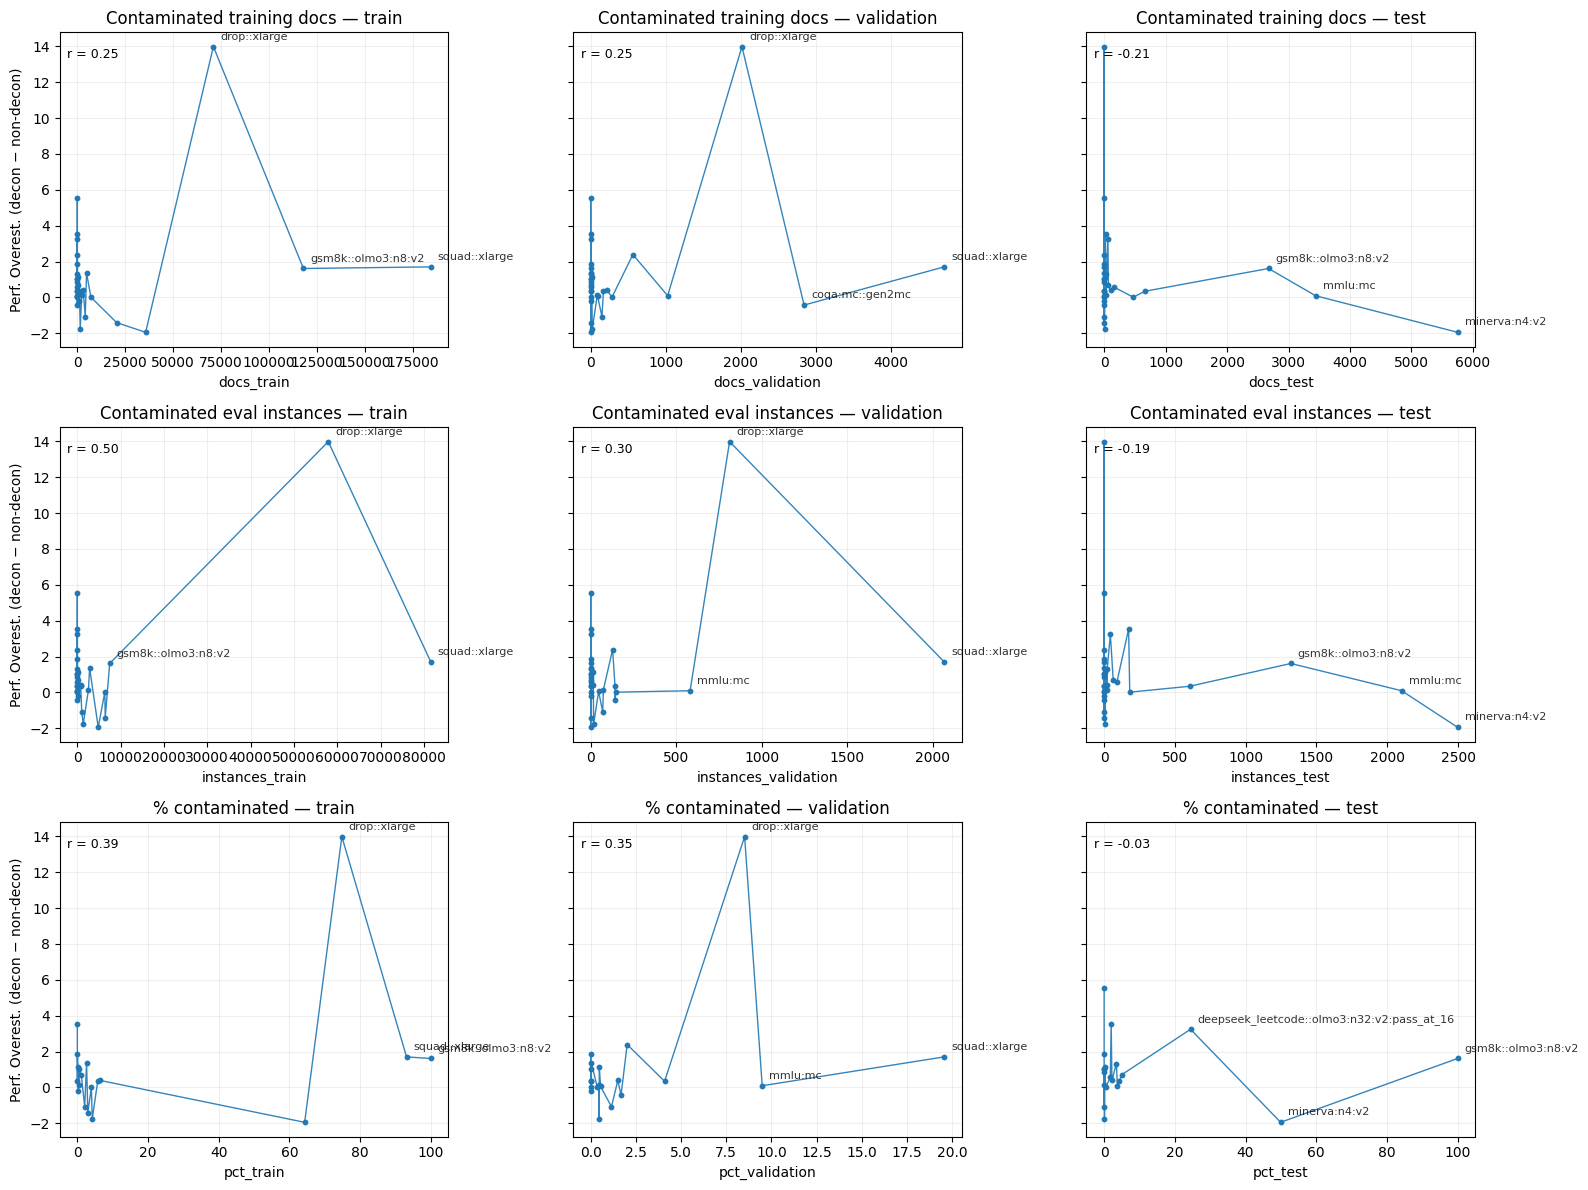

In [14]:
# Line graphs: y = performance_diff; x = split metrics; 3x3 grid (rows: docs/instances/pct; cols: train/validation/test)
import matplotlib.pyplot as plt
import numpy as np

# Use the numeric pre-format DataFrame `with_perf_filtered` built above
assert 'with_perf_filtered' in globals(), "Run previous cells to build with_perf_filtered"

splits = ["train", "validation", "test"]
metrics = [
    ("docs", "Contaminated training docs"),
    ("instances", "Contaminated eval instances"),
    ("pct", "% contaminated"),
]

fig, axes = plt.subplots(nrows=len(metrics), ncols=len(splits), figsize=(16, 12), sharey=True)
for i, (metric, mlabel) in enumerate(metrics):
    for j, split in enumerate(splits):
        col = f"{metric}_{split}"
        ax = axes[i, j]
        if col not in with_perf_filtered.columns:
            ax.set_visible(False)
            continue
        dfp = with_perf_filtered[[col, "performance_diff", "perf_key", "eval"]].dropna(subset=[col, "performance_diff"]).copy()
        if dfp.empty:
            ax.set_visible(False)
            continue
        # Sort by x for a line plot
        dfp = dfp.sort_values(col)
        ax.plot(dfp[col].values, dfp["performance_diff"].values, marker="o", linewidth=1, markersize=3, alpha=0.9)
        # Add a light scatter overlay for clarity
        ax.scatter(dfp[col].values, dfp["performance_diff"].values, s=10, alpha=0.6)
        ax.grid(True, alpha=0.2)
        # Log scale for very large count ranges to make trends visible (docs often vary widely)
        if metric == "docs":
            try:
                if (dfp[col] > 0).all():
                    ax.set_xscale("log")
            except Exception:
                pass
        ax.set_title(f"{mlabel} — {split}")
        if j == 0:
            ax.set_ylabel("Perf. Overest. (decon − non-decon)")
        ax.set_xlabel(col)
        # Label last three points with perf_key
        try:
            last_pts = dfp.tail(3)
            for _, rrow in last_pts.iterrows():
                ax.annotate(str(rrow["perf_key"]), (rrow[col], rrow["performance_diff"]),
                            textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.8)
        except Exception:
            pass
        # Show Pearson r
        try:
            r = np.corrcoef(dfp[col].astype(float), dfp["performance_diff"].astype(float))[0, 1]
            if not np.isnan(r):
                ax.text(0.02, 0.95, f"r = {r:.2f}", transform=ax.transAxes, va="top", ha="left", fontsize=9)
        except Exception:
            pass

plt.tight_layout()
plt.show()


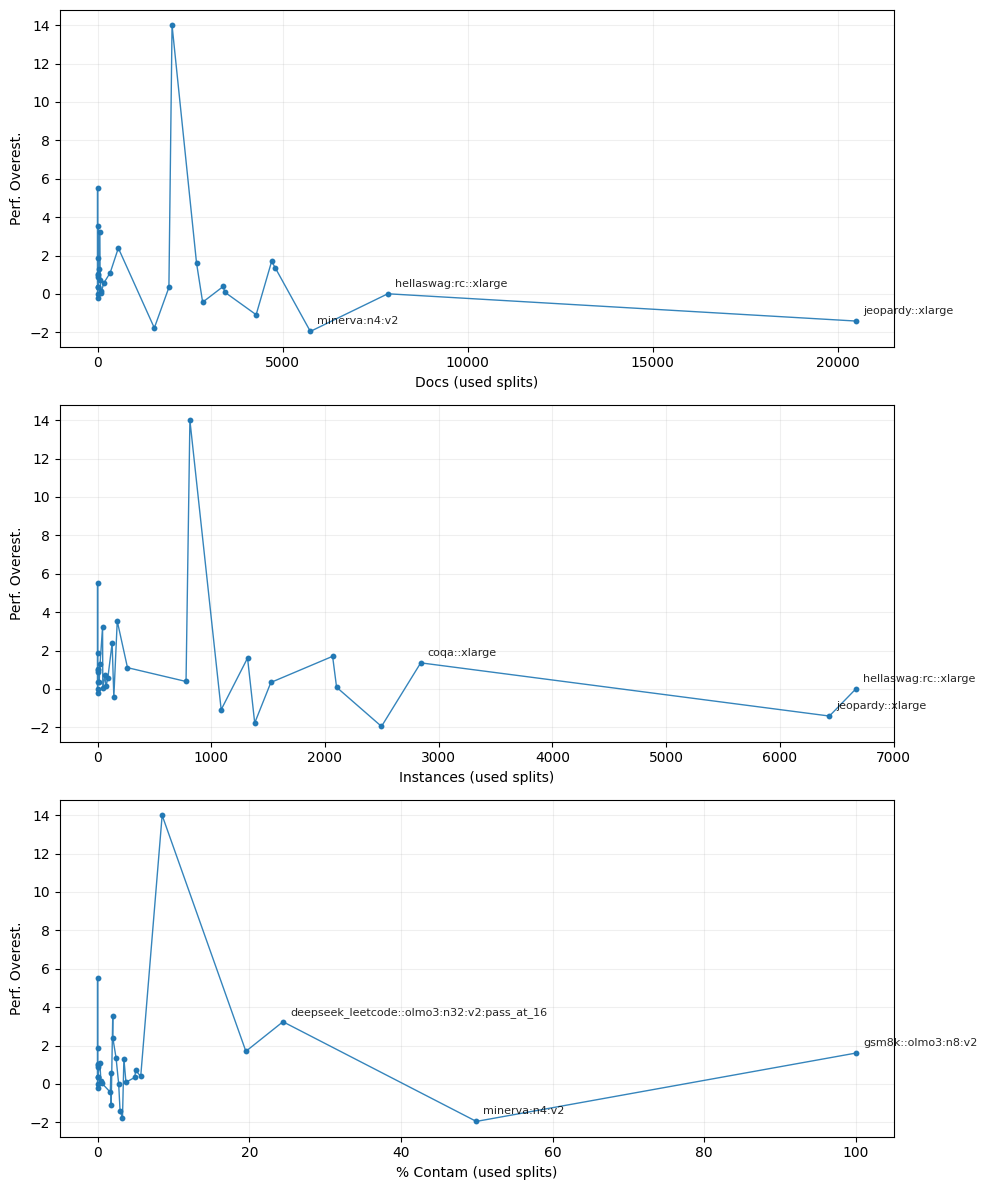

In [15]:
# Aggregate over evaluation-used splits per perf_key and plot 3-row subplots
import matplotlib.pyplot as plt
import numpy as np

assert 'with_perf_filtered' in globals(), "Run previous cells first"

# Map perf_key -> which eval splits were used
ALL_SPLITS = {"train", "validation", "test"}
TEST_ONLY_BASES = {
    "mmlu", "gsm8k", "gsm-symb", "minerva", "minerva_math_500", "medqa_en",
    "lambada", "ds1000", "codex_humaneval", "fim", "deepseek_leetcode",
    "mbpp", "multipl-e-humaneval", "multipl-e-mbpp", "cruxeval",
}
ALL_UNION_BASES = {"arc", "csqa", "piqa", "sciq", "socialiqa", "hellaswag", "winogrande"}
VAL_ONLY_BASES = {"drop", "naturalqs", "squad"}


def splits_for_perf_key(perf_key: str) -> set[str]:
    k = perf_key.lower()
    # Train-heavy overrides
    if "bigcodebench:3shot" in k or k.startswith("bigcodebench:3shot"):
        return {"train"}
    if k.startswith("jeopardy::xlarge"):
        return {"train"}
    # Jeopardy MC test-only
    if k.startswith("jeopardy:mc"):
        return {"test"}

    base = k.split(":")[0]

    if base in TEST_ONLY_BASES:
        return {"test"}
    if base in ALL_UNION_BASES:
        return set(ALL_SPLITS)
    if base in VAL_ONLY_BASES:
        return {"validation"}

    # Special cases
    if base == "coqa":
        return {"validation"} if ":mc" in k else set(ALL_SPLITS)
    if base.startswith("basic_skills") or base == "basic":
        return {"validation"}
    if base == "medmcqa" and ":mc" in k:
        return {"validation"}

    # Default to test-only if unknown
    return {"test"}


def aggregate_used_splits(row):
    used = splits_for_perf_key(row["perf_key"])
    docs = sum(row.get(f"docs_{s}", 0) or 0 for s in used)
    instances = sum(row.get(f"instances_{s}", 0) or 0 for s in used)
    total = sum(row.get(f"total_{s}", 0) or 0 for s in used)
    pct = (instances / total * 100.0) if total else np.nan
    return pd.Series({
        "docs_used": docs,
        "instances_used": instances,
        "total_used": total,
        "pct_used": pct,
    })

agg = with_perf_filtered.join(with_perf_filtered.apply(aggregate_used_splits, axis=1))

# Plot: rows = docs_used / instances_used / pct_used (single column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharey=True)
rows = [("docs_used", "Docs (used splits)"), ("instances_used", "Instances (used splits)"), ("pct_used", "% Contam (used splits)")]

for ax, (col, label) in zip(axes, rows):
    dfp = agg[[col, "performance_diff", "perf_key"]].dropna(subset=[col, "performance_diff"]).copy()
    if dfp.empty:
        ax.set_visible(False)
        continue
    dfp = dfp.sort_values(col)
    ax.plot(dfp[col].values, dfp["performance_diff"].values, marker="o", linewidth=1, markersize=3, alpha=0.9)
    ax.scatter(dfp[col].values, dfp["performance_diff"].values, s=10, alpha=0.6)
    if col in {"docs_used", "instances_used"}:
        try:
            if (dfp[col] > 0).all():
                ax.set_xscale("log")
        except Exception:
            pass
    ax.grid(True, alpha=0.2)
    ax.set_xlabel(label)
    ax.set_ylabel("Perf. Overest.")
    # Label last three points with perf_key
    for _, r in dfp.tail(3).iterrows():
        ax.annotate(str(r["perf_key"]), (r[col], r["performance_diff"]), textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.85)

plt.tight_layout()
plt.show()
